#Code with the topic: How to prune tree regression 

#Description:

#The purpose of this code is to explain how to use TreeRegression and its code structure 

#Technologies used:

#Pandas
#Visual Studio Code
#Python
#Jupyter notebook


#Method used:

DecisionTreeRegression

#How to use the code:

#We use this code as a guide to understand how to code and structure a regression tree


In [3]:
#We import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

In [4]:
#We load  dataset

data = pd.read_csv("How_to_prune_regression_on_trees.csv")

In [6]:
data.dtypes

size        int64
rooms       int64
age         int64
distance    int64
price       int64
dtype: object

In [ ]:
#We see our data in a table

data.head()

,size,rooms,age,distance,price
0,50,2,10,5,150
1,60,3,8,4,200
2,80,3,5,3,250
3,100,4,2,2,300
4,120,3,1,1,350


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   size      15 non-null     int64
 1   rooms     15 non-null     int64
 2   age       15 non-null     int64
 3   distance  15 non-null     int64
 4   price     15 non-null     int64
dtypes: int64(5)
memory usage: 732.0 bytes


In [ ]:
data.describe()

,size,rooms,age,distance,price
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,79.666667,3.200000,7.000000,5.400000,227.266667
std,27.804590,1.082326,5.503246,7.576279,102.639777
min,40.000000,1.000000,1.000000,1.000000,29.000000
25%,57.500000,3.000000,2.500000,2.500000,160.000000
50%,80.000000,3.000000,6.000000,4.000000,220.000000
75%,97.500000,4.000000,9.500000,5.000000,290.000000
max,130.000000,5.000000,20.000000,32.000000,400.000000


In [ ]:
#We deine X and Y 

X = data.drop(columns=["price"])
Y = data["price"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [ ]:
#unpruned tree 


tree = DecisionTreeRegressor(random_state=42)
tree.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
#get pruning path


path = tree.cost_complexity_pruning_path(x_train,y_train)
ccp_alphas = path.ccp_alphas

print("Available Alphas: ")
print(ccp_alphas)

Available Alphas: 
[0.00000000e+00 4.16666667e+00 4.16666667e+00 1.25000000e+01
 1.66666667e+01 3.75000000e+01 8.88888889e+01 1.12500000e+02
 4.10888889e+02 1.08888889e+03 1.91168056e+03 7.67084028e+03]


In [ ]:
trees = []
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_scores.append(mean_squared_error(y_train, y_train_pred))
    test_scores.append(mean_squared_error(y_test, y_test_pred))

    trees.append(model)

In [ ]:
#Choose the best model

best_index = np.argmin(test_scores)
best_alpha = ccp_alphas[best_index]

print("Best alpha:", best_alpha)
print("Error en test:", test_scores[best_index])

Best alpha: 0.0
Error en test: 1166.6666666666667


In [ ]:
#deliver the final pruned tree

pruned_tree = DecisionTreeRegressor(
    random_state=42,
    ccp_alpha=best_alpha
)

pruned_tree.fit(x_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,np.float64(0.0)


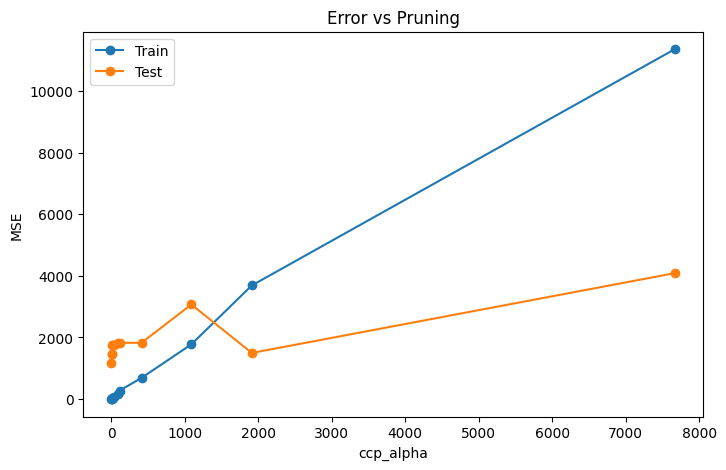

In [ ]:
#Plotting error vs. pruning

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_scores, label="Train", marker='o')
plt.plot(ccp_alphas, test_scores, label="Test", marker='o')
plt.xlabel("ccp_alpha")
plt.ylabel("MSE")
plt.title("Error vs Pruning")
plt.legend()
plt.show()

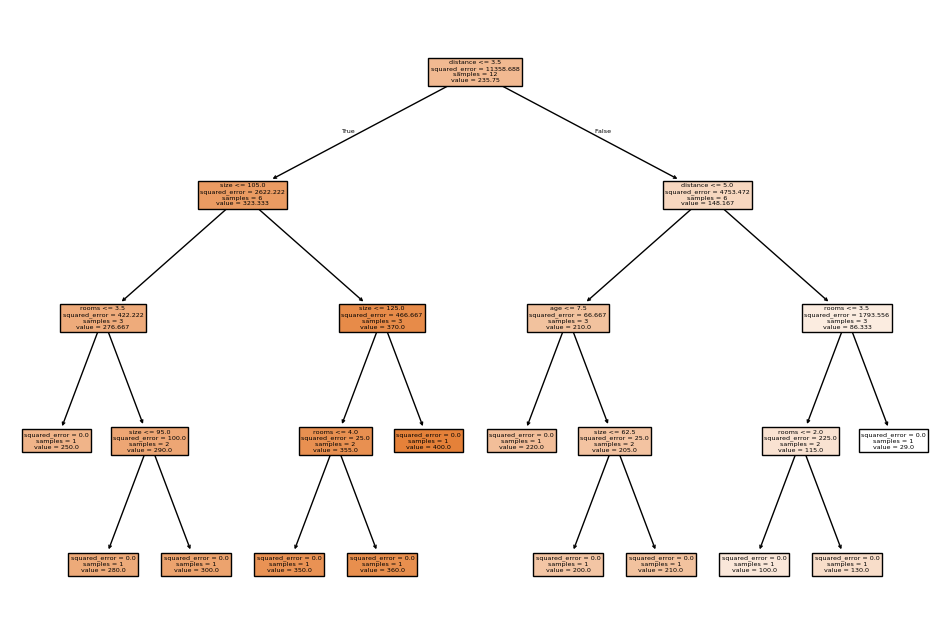

In [ ]:
#view the pruned tree

plt.figure(figsize=(12,8))
plot_tree(pruned_tree, feature_names=X.columns, filled=True)
plt.show()